# COVID-19 Worldwide — Análise Exploratória (EDA)

Este notebook documenta o processo de análise exploratória do dataset global de COVID-19 (snapshot agregado, 221 países/territórios), que serve de base para o [dashboard interativo em Streamlit](../app.py) deste projeto.

**Objetivo:** entender o alcance da pandemia por país e continente, comparar indicadores absolutos e per capita, e investigar a relação entre volume de testagem e casos detectados.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 1. Carregamento e inspeção inicial dos dados

In [2]:
df = pd.read_csv("worldwide_covid_data.csv")
df = df.rename(columns={
    "Country/Other": "Country",
    "Tot Cases/ 1M pop": "Cases per 1M",
    "Deaths/ 1M pop": "Deaths per 1M",
    "Tests/ 1M pop": "Tests per 1M",
})
print(df.shape)
df.head()


(221, 10)


,Country,Total Cases,Total Deaths,Total Recovered,Active Cases,Cases per 1M,Deaths per 1M,Total Tests,Tests per 1M,Population
0,Afghanistan,225659,7946,"206,248.00","11,465.00",5537,195,"1,302,555.00","31,961.00",40754388
1,Albania,334726,3602,"329,428.00","1,696.00",116777,1257,"1,941,032.00","677,173.00",2866374
2,Algeria,271852,6881,"183,061.00","81,910.00",5995,152,"230,960.00","5,093.00",45350148
3,Andorra,48015,165,"47,563.00",287.00,619844,2130,"249,838.00","3,225,256.00",77463
4,Angola,105384,1934,"103,419.00",31.00,3009,55,"1,499,795.00","42,818.00",35027343


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          221 non-null    str    
 1   Total Cases      221 non-null    int64  
 2   Total Deaths     221 non-null    int64  
 3   Total Recovered  201 non-null    float64
 4   Active Cases     201 non-null    float64
 5   Cases per 1M     221 non-null    int64  
 6   Deaths per 1M    221 non-null    int64  
 7   Total Tests      211 non-null    float64
 8   Tests per 1M     211 non-null    float64
 9   Population       221 non-null    int64  
dtypes: float64(4), int64(5), str(1)
memory usage: 19.2 KB


### Dicionário de dados

| Coluna | Descrição |
|---|---|
| Country | Nome do país ou território |
| Total Cases | Total de casos confirmados de COVID-19 |
| Total Deaths | Total de mortes |
| Total Recovered | Total de casos recuperados |
| Active Cases | Casos ativos no momento do snapshot |
| Cases per 1M | Casos totais por 1 milhão de habitantes |
| Deaths per 1M | Mortes totais por 1 milhão de habitantes |
| Total Tests | Total de testes de COVID-19 realizados |
| Tests per 1M | Testes por 1 milhão de habitantes |
| Population | População do país |


## 2. Qualidade e validação dos dados

In [4]:
# Valores ausentes
missing = df.isna().sum()
missing[missing > 0]


Total Recovered    20
Active Cases       20
Total Tests        10
Tests per 1M       10
dtype: int64

`Total Recovered` e `Active Cases` faltam em 20 países; `Total Tests` e `Tests per 1M` faltam em 10 países — provavelmente países que não divulgaram dados de testagem ou de recuperação de forma consistente. Vamos mantê-los como `NaN` (não preencher com 0, que distorceria as análises) e tratar caso a caso nas métricas derivadas.

In [5]:
# Duplicatas
print("Linhas duplicadas:", df.duplicated().sum())
print("Países duplicados:", df["Country"].duplicated().sum())

# Valores negativos (não deveriam existir em nenhuma coluna numérica)
num_cols = df.select_dtypes(include="number").columns
print("\nValores negativos por coluna:")
print((df[num_cols] < 0).sum())


Linhas duplicadas: 0
Países duplicados: 0

Valores negativos por coluna:
Total Cases        0
Total Deaths       0
Total Recovered    0
Active Cases       0
Cases per 1M       0
Deaths per 1M      0
Total Tests        0
Tests per 1M       0
Population         0
dtype: int64


In [6]:
# Checagem de consistência interna: Casos totais ~= Mortes + Recuperados + Ativos
check = df.dropna(subset=["Total Recovered", "Active Cases"]).copy()
check["soma_componentes"] = check["Total Deaths"] + check["Total Recovered"] + check["Active Cases"]
check["diferenca"] = check["Total Cases"] - check["soma_componentes"]
check["diferenca"].describe()


count   201.00
mean      0.00
std       0.00
min       0.00
25%       0.00
50%       0.00
75%       0.00
max       0.00
Name: diferenca, dtype: float64

A diferença é **zero para todas as linhas com dados completos** — o dataset é internamente consistente (Casos = Mortes + Recuperados + Ativos). Isso dá confiança para seguir com a análise sem necessidade de reconciliação.

## 3. Enriquecimento: mapeamento de continentes

In [9]:
with open("continent_mapping.json", encoding="utf-8") as f:
    geo_map = json.load(f)

df["Continent"] = df["Country"].map(lambda c: geo_map.get(c, {}).get("continent"))
df["ISO3"] = df["Country"].map(lambda c: geo_map.get(c, {}).get("iso3"))
df["Continent"].value_counts()


Continent
Africa           56
Asia             50
Europe           48
North America    37
Oceania          17
South America    13
Name: count, dtype: int64

O mapeamento país → continente foi construído com a biblioteca `pycountry` / `pycountry-convert`, com um pequeno dicionário de aliases manuais para nomes abreviados ou não padronizados no dataset original (ex.: `USA`, `UK`, `S. Korea`, `DPRK`, `DRC`, `CAR`). O resultado foi salvo em `data/continent_mapping.json` e é reutilizado pelo dashboard.

## 4. Métricas derivadas

In [10]:
df["Mortality Rate (%)"] = (df["Total Deaths"] / df["Total Cases"] * 100).round(2)
df["Recovery Rate (%)"] = (df["Total Recovered"] / df["Total Cases"] * 100).round(2)
df["Tests per Case"] = (df["Total Tests"] / df["Total Cases"]).round(2)

# Para rankings per capita, filtramos microestados (população < 1M) que distorcem as taxas
big = df[df["Population"] >= 1_000_000].copy()
print(f"Países com população >= 1M: {len(big)} de {len(df)}")


Países com população >= 1M: 158 de 221


## 5. Perguntas do projeto

As perguntas abaixo guiam a análise e alimentam diretamente as abas do dashboard:

1. Quais países tiveram o maior número **absoluto** de casos e mortes?
2. Quais países tiveram o maior número de casos e mortes **por 1 milhão de habitantes** (ajustado por tamanho de população)?
3. Quais países têm a maior e a menor **taxa de mortalidade** (mortes / casos)?
4. Como os **continentes** se comparam em termos de casos e mortes?
5. Existe relação entre o **volume de testagem** e o número de casos detectados por país?
6. Quais países chamam atenção por **inconsistência ou possível subnotificação** nos dados?


### 5.1 Quais países tiveram o maior número absoluto de casos e mortes?

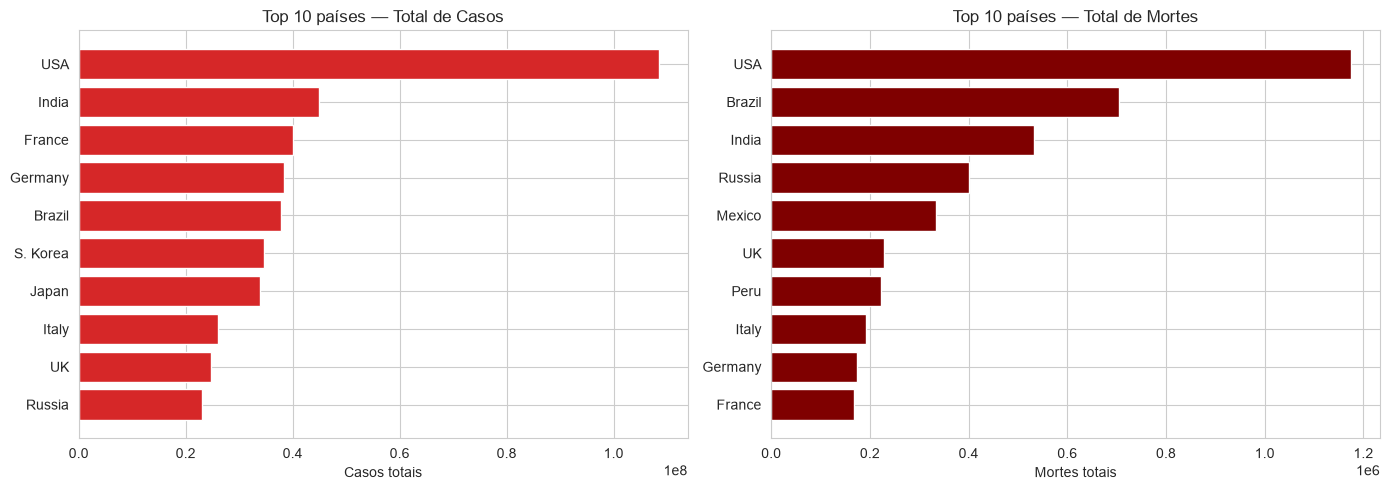

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_cases = df.nlargest(10, "Total Cases").sort_values("Total Cases")
axes[0].barh(top_cases["Country"], top_cases["Total Cases"], color="#d62728")
axes[0].set_title("Top 10 países — Total de Casos")
axes[0].set_xlabel("Casos totais")

top_deaths = df.nlargest(10, "Total Deaths").sort_values("Total Deaths")
axes[1].barh(top_deaths["Country"], top_deaths["Total Deaths"], color="#7f0000")
axes[1].set_title("Top 10 países — Total de Mortes")
axes[1].set_xlabel("Mortes totais")

plt.tight_layout()
plt.show()


In [12]:
df.nlargest(5, "Total Cases")[["Country", "Total Cases", "Total Deaths", "Population"]]


,Country,Total Cases,Total Deaths,Population
209,USA,108386688,1174847,334805269
92,India,44997917,531930,1406631776
70,France,40138560,167642,65584518
76,Germany,38428685,174352,83883596
26,Brazil,37789040,705313,215353593


**Achado:** EUA, Índia, França, Alemanha e Brasil concentram os maiores volumes absolutos — resultado esperado, já que casos absolutos tendem a acompanhar o tamanho da população. Isso reforça a necessidade de olhar também as métricas per capita (próxima seção) para uma comparação justa entre países.

### 5.2 Quais países tiveram o maior número de casos e mortes por 1M habitantes?

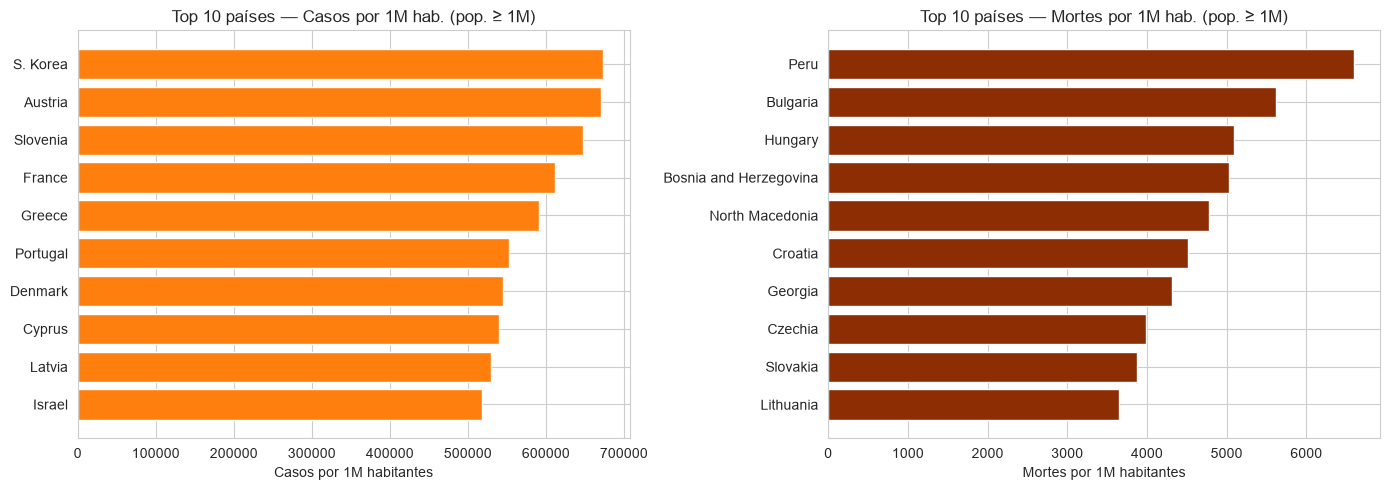

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_cases_pc = big.nlargest(10, "Cases per 1M").sort_values("Cases per 1M")
axes[0].barh(top_cases_pc["Country"], top_cases_pc["Cases per 1M"], color="#ff7f0e")
axes[0].set_title("Top 10 países — Casos por 1M hab. (pop. ≥ 1M)")
axes[0].set_xlabel("Casos por 1M habitantes")

top_deaths_pc = big.nlargest(10, "Deaths per 1M").sort_values("Deaths per 1M")
axes[1].barh(top_deaths_pc["Country"], top_deaths_pc["Deaths per 1M"], color="#8c2d04")
axes[1].set_title("Top 10 países — Mortes por 1M hab. (pop. ≥ 1M)")
axes[1].set_xlabel("Mortes por 1M habitantes")

plt.tight_layout()
plt.show()


**Achado:** ao ajustar por população, o ranking muda completamente. Coreia do Sul, Áustria, Eslovênia e França lideram em casos por habitante, enquanto **Peru, Bulgária e Hungria** lideram em mortes por habitante — nenhum desses aparece no top 10 absoluto. Isso mostra como olhar só para números absolutos pode enviesar a leitura sobre onde a pandemia foi, proporcionalmente, mais severa.

### 5.3 Quais países têm a maior e a menor taxa de mortalidade (CFR)?

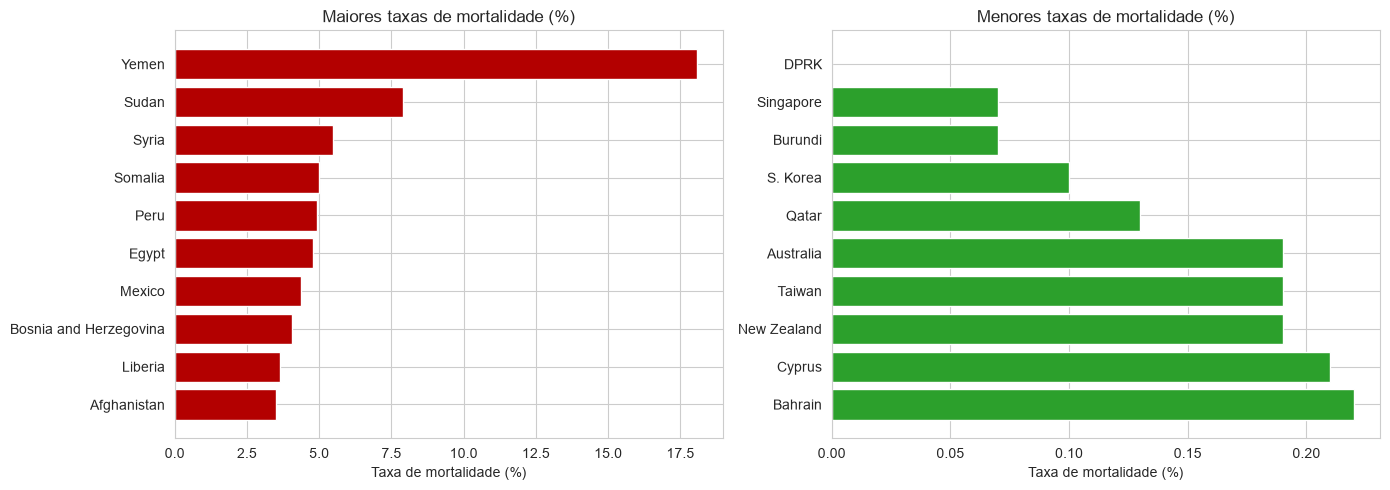

In [14]:
cfr_base = df[(df["Population"] >= 1_000_000) & (df["Total Cases"] > 1000)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

highest_cfr = cfr_base.nlargest(10, "Mortality Rate (%)").sort_values("Mortality Rate (%)")
axes[0].barh(highest_cfr["Country"], highest_cfr["Mortality Rate (%)"], color="#b30000")
axes[0].set_title("Maiores taxas de mortalidade (%)")
axes[0].set_xlabel("Taxa de mortalidade (%)")

lowest_cfr = cfr_base.nsmallest(10, "Mortality Rate (%)").sort_values("Mortality Rate (%)", ascending=False)
axes[1].barh(lowest_cfr["Country"], lowest_cfr["Mortality Rate (%)"], color="#2ca02c")
axes[1].set_title("Menores taxas de mortalidade (%)")
axes[1].set_xlabel("Taxa de mortalidade (%)")

plt.tight_layout()
plt.show()


In [13]:
cfr_base.nlargest(5, "Mortality Rate (%)")[["Country", "Mortality Rate (%)", "Total Cases", "Total Tests", "Tests per 1M"]]


,Country,Mortality Rate (%),Total Cases,Total Tests,Tests per 1M
218,Yemen,18.07,11945,"329,592.00","10,579.00"
191,Sudan,7.89,63993,"562,941.00","12,240.00"
195,Syria,5.48,57743,"146,269.00","7,553.00"
184,Somalia,4.98,27334,"400,466.00","23,778.00"
157,Peru,4.92,4519976,"39,010,194.00","1,158,115.00"


**Achado:** Iêmen (18%), Sudão (7,9%) e Síria (5,5%) têm as maiores taxas de mortalidade — e também estão entre os países com **menor volume de testes por habitante**, o que sugere subnotificação de casos leves (só os casos mais graves chegam a ser testados e confirmados), inflando artificialmente a taxa de mortalidade aparente. Já Coreia do Sul, Cingapura e Austrália têm taxas abaixo de 0,2%, associadas a sistemas de testagem e saúde mais robustos.

### 5.4 Como os continentes se comparam?

In [16]:
cont_agg = df.groupby("Continent")[["Total Cases", "Total Deaths"]].sum().sort_values("Total Cases", ascending=False)
cont_agg["Mortality Rate (%)"] = (cont_agg["Total Deaths"] / cont_agg["Total Cases"] * 100).round(2)
cont_agg


,Total Cases,Total Deaths,Mortality Rate (%)
Continent,,,
Europe,249993251,2071157,0.83
Asia,220727365,1549637,0.70
North America,128068696,1644588,1.28
South America,68978995,1360574,1.97
Oceania,14634868,30317,0.21
Africa,12835347,258828,2.02


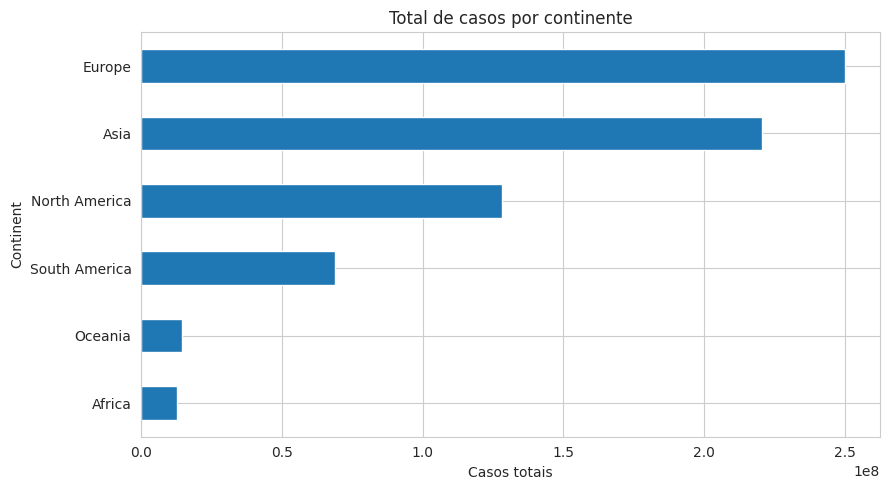

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
cont_agg["Total Cases"].sort_values().plot(kind="barh", ax=ax, color="#1f77b4")
ax.set_title("Total de casos por continente")
ax.set_xlabel("Casos totais")
plt.tight_layout()
plt.show()


**Achado:** Europa, Ásia e América do Norte concentram a maior parte dos casos registrados globalmente — refletindo tanto densidade populacional quanto maior capacidade/consistência de testagem e notificação em relação à África, por exemplo, onde a subnotificação é uma limitação conhecida.

### 5.5 Existe relação entre volume de testagem e casos detectados?

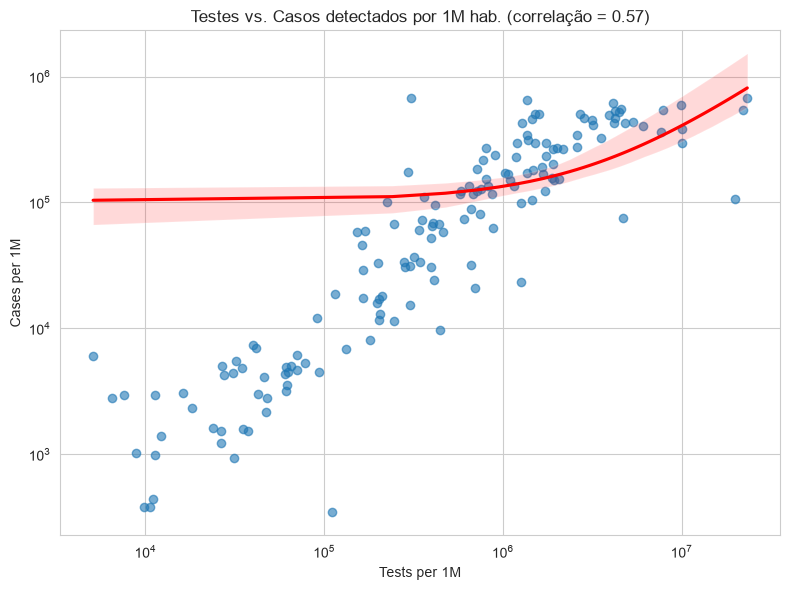

Correlação (Pearson) entre Testes/1M e Casos/1M: 0.57


In [17]:
scatter_df = big.dropna(subset=["Tests per 1M", "Cases per 1M"])
corr = scatter_df[["Tests per 1M", "Cases per 1M"]].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=scatter_df, x="Tests per 1M", y="Cases per 1M", ax=ax,
            scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title(f"Testes vs. Casos detectados por 1M hab. (correlação = {corr:.2f})")
plt.tight_layout()
plt.show()

print(f"Correlação (Pearson) entre Testes/1M e Casos/1M: {corr:.2f}")


**Achado:** a correlação moderada e positiva (≈0,5) sugere que parte da variação nos casos detectados entre países está relacionada ao volume de testagem — países que testam mais tendem a **encontrar** mais casos. Isso é um viés importante a considerar: diferenças nos números "oficiais" de casos entre países refletem tanto a realidade epidemiológica quanto a capacidade/política de testagem de cada um.

### 5.6 Países com inconsistência ou possível subnotificação

In [18]:
df[df["Country"].isin(["DPRK", "Yemen", "Sudan", "Syria", "S. Korea"])][
    ["Country", "Total Cases", "Total Deaths", "Mortality Rate (%)", "Total Tests", "Tests per 1M"]
]


,Country,Total Cases,Total Deaths,Mortality Rate (%),Total Tests,Tests per 1M
53,DPRK,4772813,74,0.00,NaN,NaN
166,S. Korea,34571873,35934,0.10,"15,804,065.00","307,892.00"
191,Sudan,63993,5046,7.89,"562,941.00","12,240.00"
195,Syria,57743,3165,5.48,"146,269.00","7,553.00"
218,Yemen,11945,2159,18.07,"329,592.00","10,579.00"


**Achado:** a Coreia do Norte (DPRK) reporta 4,77 milhões de casos, mas apenas 74 mortes (taxa de mortalidade de ~0%) e **nenhum dado de testagem** — um padrão estatisticamente improvável e amplamente reportado por veículos de imprensa como reflexo de subnotificação/manipulação de dados oficiais do regime, não de um resultado sanitário real. Esse tipo de outlier é importante sinalizar explicitamente para não distorcer conclusões (ex.: ao calcular a menor taxa de mortalidade global).

## 6. Principais conclusões

- **Volume ≠ severidade relativa.** Os países com mais casos/mortes em números absolutos (EUA, Índia, Brasil) não são os mesmos que lideram em termos per capita (Peru, Bulgária, Coreia do Sul) — análises de saúde pública precisam sempre normalizar por população.
- **Testagem molda os números oficiais.** Há correlação moderada (~0,5) entre testes por habitante e casos detectados por habitante: mais teste, mais caso confirmado. Comparações diretas entre países com políticas de testagem muito diferentes devem ser vistas com cautela.
- **Taxa de mortalidade alta pode ser sinal de subnotificação, não de gravidade clínica.** Países com conflitos ou infraestrutura de saúde limitada (Iêmen, Sudão, Síria) têm as maiores taxas de mortalidade combinadas com as menores taxas de testagem — indício de que só os casos mais graves foram capturados nos dados.
- **Qualidade de dados importa.** Ao menos um país (Coreia do Norte) apresenta um padrão de dados estatisticamente incompatível com o resto do dataset e deve ser tratado como outlier/não confiável em qualquer análise agregada.
- A mortalidade global agregada no snapshot é de aproximadamente **1%** (6,9M mortes / 695M casos).

Essas descobertas alimentam diretamente o [dashboard interativo](../app.py) — ver `README.md` para instruções de uso.
